<a href="https://colab.research.google.com/github/umiSirya/FUTURE_DS_02/blob/main/telco_churn_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [90]:
!pip install jupyter-dash dash dash-bootstrap-components --quiet


In [91]:
!pip show jupyter-dash


Name: jupyter-dash
Version: 0.4.2
Summary: Dash support for the Jupyter notebook interface
Home-page: https://github.com/plotly/jupyter-dash
Author: Plotly
Author-email: 
License: MIT
Location: /usr/local/lib/python3.12/dist-packages
Requires: ansi2html, dash, flask, ipykernel, ipython, nest-asyncio, requests, retrying
Required-by: 


In [92]:
# importing necessary libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from jupyter_dash import JupyterDash
from dash import dcc, html
import dash_bootstrap_components as dbc


In [93]:
# Upload the CSV to Colab first, then update the path if needed
dp = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")
print("Shape:", dp.shape)
print(dp.head())


Shape: (7043, 21)
   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...               No   
1                No             DSL            Yes  ...              Yes   
2                No             DSL            Yes  ...               No   
3  No phone service             DSL            Yes  ...              Yes   
4                No     Fiber optic             No  ...               No   

  TechSupport StreamingTV StreamingMovies   

# **EDA & Cleaning**

In [94]:
# Basic Info
print(dp.info())

#checking for null values
print("\nMissing values:\n", dp.isnull().sum())

#checking for duplicated values
print("\nDuplicates:", dp.duplicated().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [95]:
# TotalCharges has blank strings for new customers (tenure = 0)

dp["TotalCharges"] = pd.to_numeric(dp["TotalCharges"], errors="coerce")

In [96]:
# Inspect the rows affected
print("Rows with NaN TotalCharges:")
print(dp[dp["TotalCharges"].isna()][["customerID", "tenure", "MonthlyCharges", "TotalCharges"]])

Rows with NaN TotalCharges:
      customerID  tenure  MonthlyCharges  TotalCharges
488   4472-LVYGI       0           52.55           NaN
753   3115-CZMZD       0           20.25           NaN
936   5709-LVOEQ       0           80.85           NaN
1082  4367-NUYAO       0           25.75           NaN
1340  1371-DWPAZ       0           56.05           NaN
3331  7644-OMVMY       0           19.85           NaN
3826  3213-VVOLG       0           25.35           NaN
4380  2520-SGTTA       0           20.00           NaN
5218  2923-ARZLG       0           19.70           NaN
6670  4075-WKNIU       0           73.35           NaN
6754  2775-SEFEE       0           61.90           NaN


In [97]:
# Fill NaN TotalCharges with 0 — these are brand-new customers
dp["TotalCharges"] = dp["TotalCharges"].fillna(0)

print("\nAfter fix — missing values:\n", dp.isnull().sum())


After fix — missing values:
 customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


In [98]:
# Create a numeric version of Churn for calculations

dp["ChurnFlag"] = dp["Churn"].map({"Yes": 1, "No": 0})
print("Churn distribution:\n", dp["Churn"].value_counts())
print("\nOverall churn rate: {:.1f}%".format(dp["ChurnFlag"].mean() * 100))

Churn distribution:
 Churn
No     5174
Yes    1869
Name: count, dtype: int64

Overall churn rate: 26.5%


In [99]:
# Encode SeniorCitizen as readable label
dp["SeniorCitizenLabel"] = dp["SeniorCitizen"].map({0: "Non-Senior", 1: "Senior"})


In [100]:
# Tenure Buckets

bins = [0, 12, 24, 48, 72]
labels = ["0–12 mo", "13–24 mo", "25–48 mo", "49–72 mo"]
dp["TenureBucket"] = pd.cut(dp["tenure"], bins=bins, labels=labels, right=True)
print(dp["TenureBucket"].value_counts().sort_index())


TenureBucket
0–12 mo     2175
13–24 mo    1024
25–48 mo    1594
49–72 mo    2239
Name: count, dtype: int64


In [101]:

# Summary Statistics

print("=== Numeric Summary ===")
print(dp[["tenure", "MonthlyCharges", "TotalCharges"]].describe().round(2))

print("\n=== Churn Rate by Contract Type ===")
print(dp.groupby("Contract")["ChurnFlag"].mean().mul(100).round(1).rename("Churn %"))

print("\n=== Churn Rate by Internet Service ===")
print(dp.groupby("InternetService")["ChurnFlag"].mean().mul(100).round(1).rename("Churn %"))

print("\n=== Churn Rate by Payment Method ===")
print(dp.groupby("PaymentMethod")["ChurnFlag"].mean().mul(100).round(1).rename("Churn %"))

print("\n=== Churn Rate by Tenure Bucket ===")
print(dp.groupby("TenureBucket", observed=True)["ChurnFlag"].mean().mul(100).round(1).rename("Churn %"))

print("\n=== Avg Monthly Charges — Churned vs Retained ===")
print(dp.groupby("Churn")[["MonthlyCharges", "TotalCharges"]].mean().round(2))

=== Numeric Summary ===
        tenure  MonthlyCharges  TotalCharges
count  7043.00         7043.00       7043.00
mean     32.37           64.76       2279.73
std      24.56           30.09       2266.79
min       0.00           18.25          0.00
25%       9.00           35.50        398.55
50%      29.00           70.35       1394.55
75%      55.00           89.85       3786.60
max      72.00          118.75       8684.80

=== Churn Rate by Contract Type ===
Contract
Month-to-month    42.7
One year          11.3
Two year           2.8
Name: Churn %, dtype: float64

=== Churn Rate by Internet Service ===
InternetService
DSL            19.0
Fiber optic    41.9
No              7.4
Name: Churn %, dtype: float64

=== Churn Rate by Payment Method ===
PaymentMethod
Bank transfer (automatic)    16.7
Credit card (automatic)      15.2
Electronic check             45.3
Mailed check                 19.1
Name: Churn %, dtype: float64

=== Churn Rate by Tenure Bucket ===
TenureBucket
0–12 mo     

In [102]:
# Save Cleaned Dataset
dp.to_csv("clean_telco.csv", index=False)
print("Saved: clean_telco.csv")

Saved: clean_telco.csv


# **Visualizations**

In [103]:


PALETTE_CHURN = {"No": "#4472C4", "Yes": "#E05C5C"}   # blue = retained, red = churned
PALETTE_MAIN  = "Blues_d"
sns.set_theme(style="whitegrid", font_scale=1.1)

# Load cleaned data

dp = pd.read_csv("clean_telco.csv")
dp["TenureBucket"] = pd.Categorical(
    dp["TenureBucket"],
    categories=["0–12 mo", "13–24 mo", "25–48 mo", "49–72 mo"],
    ordered=True
)


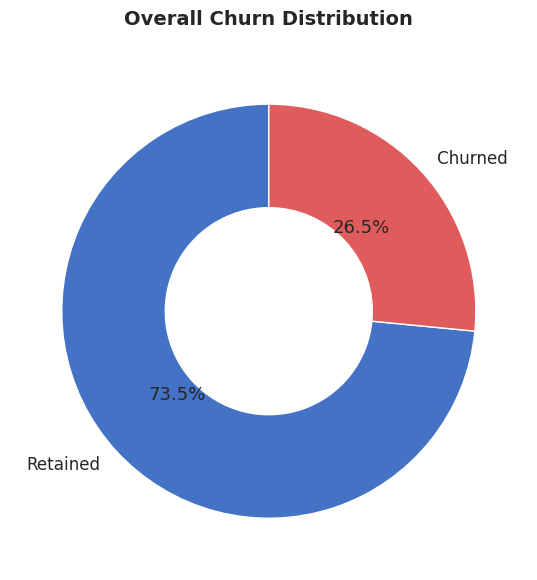

In [104]:
#  Overall Churn Distribution (Donut Chart)
churn_counts = dp["Churn"].value_counts()
colors = ["#4472C4", "#E05C5C"]

fig, ax = plt.subplots(figsize=(6, 6))
wedges, texts, autotexts = ax.pie(
    churn_counts,
    labels=["Retained", "Churned"],
    colors=colors,
    autopct="%1.1f%%",
    startangle=90,
    wedgeprops=dict(width=0.5)
)
for t in autotexts:
    t.set_fontsize(13)
ax.set_title("Overall Churn Distribution", fontsize=14, fontweight="bold", pad=20)
plt.tight_layout()
plt.show()


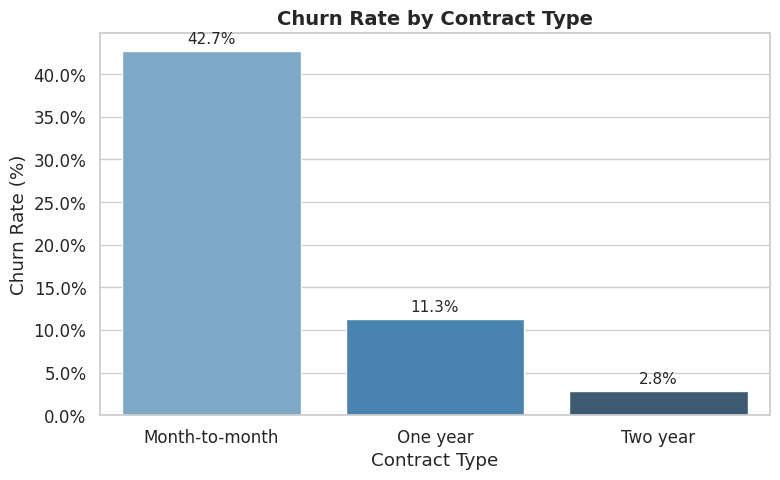

In [105]:

# Churn Rate by Contract Type
contract_churn = (
    dp.groupby("Contract")["ChurnFlag"]
    .mean()
    .mul(100)
    .reset_index()
    .rename(columns={"ChurnFlag": "ChurnRate"})
    .sort_values("ChurnRate", ascending=False)
)

fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(data=contract_churn, x="Contract", y="ChurnRate",
            hue="Contract", palette="Blues_d", legend=False, ax=ax)
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.set_title("Churn Rate by Contract Type", fontsize=14, fontweight="bold")
ax.set_xlabel("Contract Type")
ax.set_ylabel("Churn Rate (%)")
for bar in ax.patches:
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.5,
            f"{bar.get_height():.1f}%",
            ha="center", va="bottom", fontsize=11)
plt.tight_layout()
plt.show()

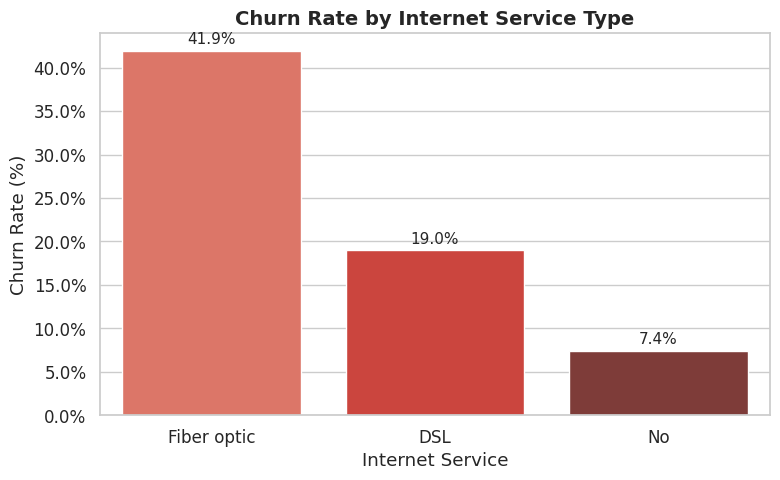

In [106]:

# Churn Rate by Internet Service
internet_churn = (
    dp.groupby("InternetService")["ChurnFlag"]
    .mean()
    .mul(100)
    .reset_index()
    .rename(columns={"ChurnFlag": "ChurnRate"})
    .sort_values("ChurnRate", ascending=False)
)

fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(data=internet_churn, x="InternetService", y="ChurnRate",
            hue="InternetService", palette="Reds_d", legend=False, ax=ax)
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.set_title("Churn Rate by Internet Service Type", fontsize=14, fontweight="bold")
ax.set_xlabel("Internet Service")
ax.set_ylabel("Churn Rate (%)")
for bar in ax.patches:
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.5,
            f"{bar.get_height():.1f}%",
            ha="center", va="bottom", fontsize=11)
plt.tight_layout()
plt.show()

/tmp/ipykernel_725/2028398280.py:18: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=15, ha="right")


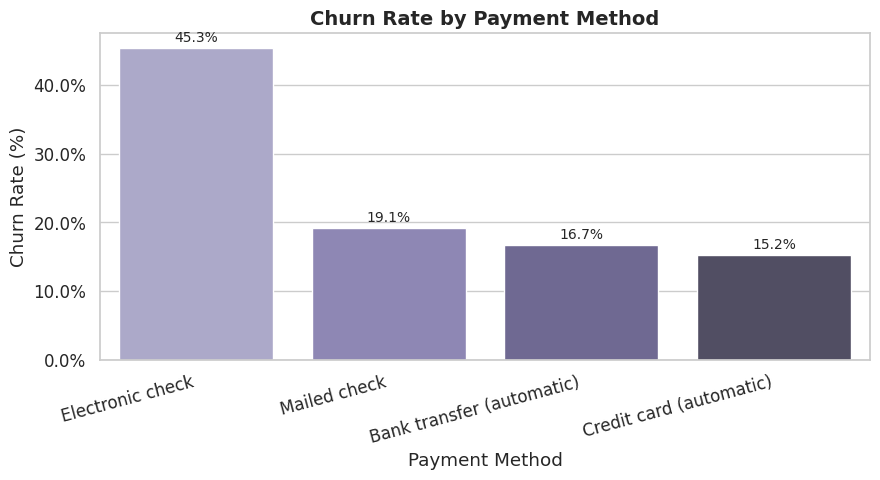

In [107]:
# Churn Rate by Payment Method
payment_churn = (
    dp.groupby("PaymentMethod")["ChurnFlag"]
    .mean()
    .mul(100)
    .reset_index()
    .rename(columns={"ChurnFlag": "ChurnRate"})
    .sort_values("ChurnRate", ascending=False)
)

fig, ax = plt.subplots(figsize=(9, 5))
sns.barplot(data=payment_churn, x="PaymentMethod", y="ChurnRate",
            hue="PaymentMethod", palette="Purples_d", legend=False, ax=ax)
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.set_title("Churn Rate by Payment Method", fontsize=14, fontweight="bold")
ax.set_xlabel("Payment Method")
ax.set_ylabel("Churn Rate (%)")
ax.set_xticklabels(ax.get_xticklabels(), rotation=15, ha="right")
for bar in ax.patches:
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.5,
            f"{bar.get_height():.1f}%",
            ha="center", va="bottom", fontsize=10)
plt.tight_layout()
plt.show()

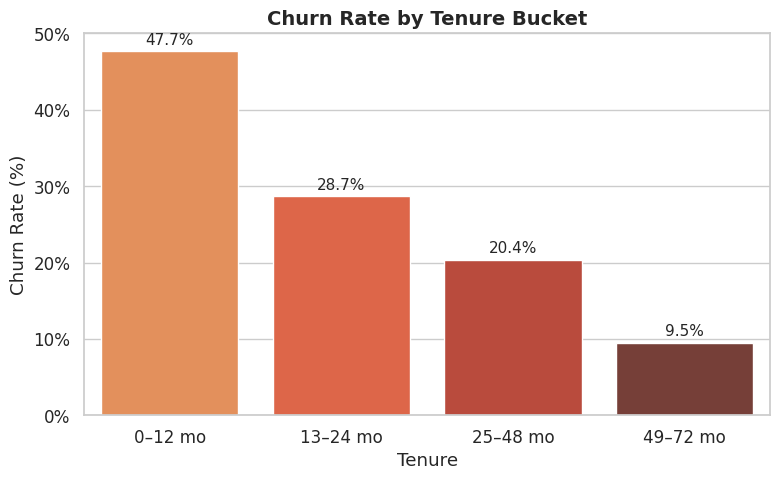

In [108]:
# Churn Rate by Tenure Bucket
tenure_churn = (
    dp.groupby("TenureBucket", observed=True)["ChurnFlag"]
    .mean()
    .mul(100)
    .reset_index()
    .rename(columns={"ChurnFlag": "ChurnRate"})
)

fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(data=tenure_churn, x="TenureBucket", y="ChurnRate",
            hue="TenureBucket", palette="YlOrRd_d", legend=False, ax=ax)
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.set_title("Churn Rate by Tenure Bucket", fontsize=14, fontweight="bold")
ax.set_xlabel("Tenure")
ax.set_ylabel("Churn Rate (%)")
for bar in ax.patches:
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.5,
            f"{bar.get_height():.1f}%",
            ha="center", va="bottom", fontsize=11)
plt.tight_layout()
plt.show()

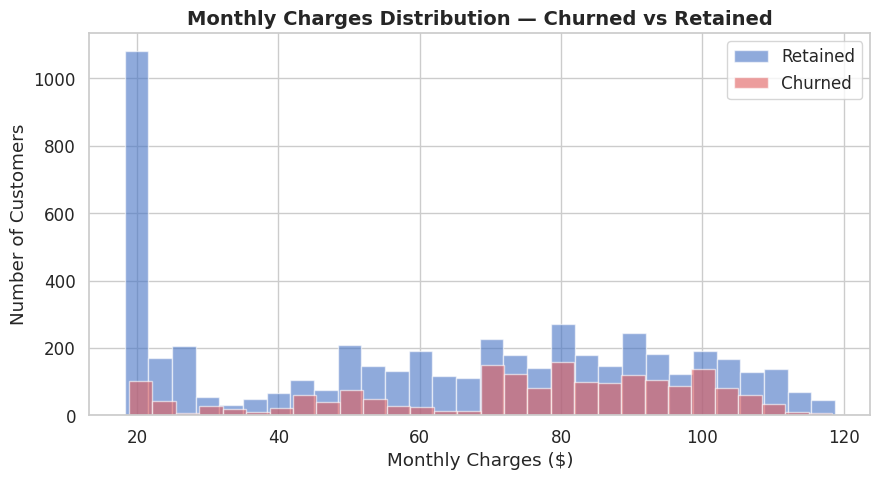

In [109]:
# Monthly Charges Distribution — Churned vs Retained
fig, ax = plt.subplots(figsize=(9, 5))
for label, color in PALETTE_CHURN.items():
    subset = dp[dp["Churn"] == label]["MonthlyCharges"]
    ax.hist(subset, bins=30, alpha=0.6, color=color,
            label="Churned" if label == "Yes" else "Retained", edgecolor="white")
ax.set_title("Monthly Charges Distribution — Churned vs Retained",
             fontsize=14, fontweight="bold")
ax.set_xlabel("Monthly Charges ($)")
ax.set_ylabel("Number of Customers")
ax.legend()
plt.tight_layout()
plt.show()

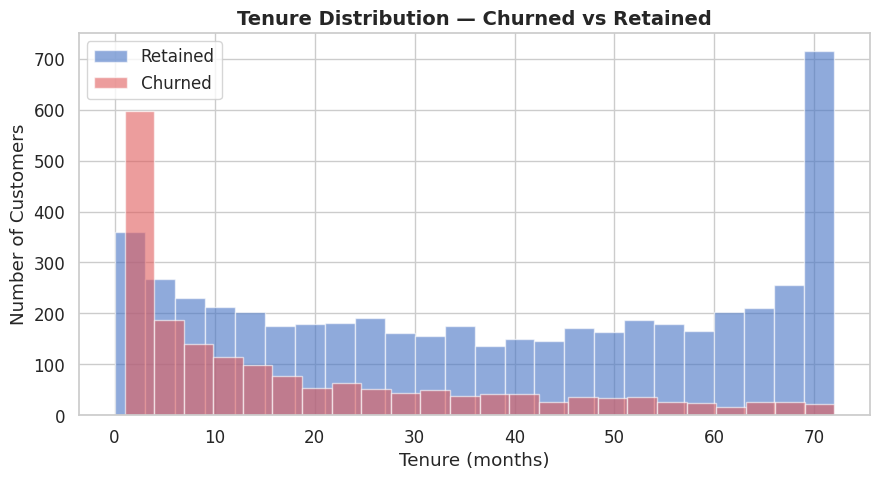

In [110]:

# Tenure Distribution — Churned vs Retained
fig, ax = plt.subplots(figsize=(9, 5))
for label, color in PALETTE_CHURN.items():
    subset = dp[dp["Churn"] == label]["tenure"]
    ax.hist(subset, bins=24, alpha=0.6, color=color,
            label="Churned" if label == "Yes" else "Retained", edgecolor="white")
ax.set_title("Tenure Distribution — Churned vs Retained",
             fontsize=14, fontweight="bold")
ax.set_xlabel("Tenure (months)")
ax.set_ylabel("Number of Customers")
ax.legend()
plt.tight_layout()
plt.show()

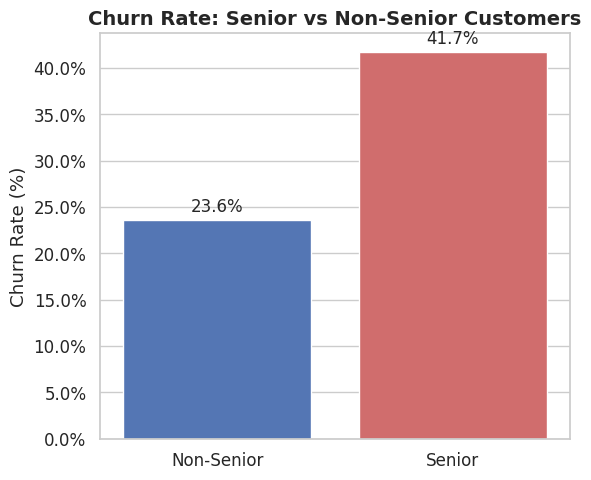

In [111]:

# Churn by Senior Citizen Status
senior_churn = (
    dp.groupby("SeniorCitizenLabel")["ChurnFlag"]
    .mean()
    .mul(100)
    .reset_index()
    .rename(columns={"ChurnFlag": "ChurnRate"})
)

fig, ax = plt.subplots(figsize=(6, 5))
sns.barplot(data=senior_churn, x="SeniorCitizenLabel", y="ChurnRate",
            hue="SeniorCitizenLabel", palette=["#4472C4", "#E05C5C"], legend=False, ax=ax)
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.set_title("Churn Rate: Senior vs Non-Senior Customers",
             fontsize=14, fontweight="bold")
ax.set_xlabel("")
ax.set_ylabel("Churn Rate (%)")
for bar in ax.patches:
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.5,
            f"{bar.get_height():.1f}%",
            ha="center", va="bottom", fontsize=12)
plt.tight_layout()
plt.show()

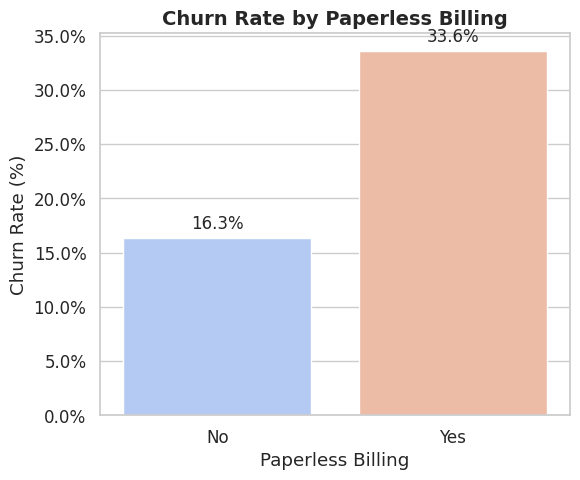

In [112]:
# Churn by Paperless Billing
billing_churn = (
    dp.groupby("PaperlessBilling")["ChurnFlag"]
    .mean()
    .mul(100)
    .reset_index()
    .rename(columns={"ChurnFlag": "ChurnRate"})
)

fig, ax = plt.subplots(figsize=(6, 5))
sns.barplot(data=billing_churn, x="PaperlessBilling", y="ChurnRate",
            hue="PaperlessBilling", palette="coolwarm", legend=False, ax=ax)
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.set_title("Churn Rate by Paperless Billing", fontsize=14, fontweight="bold")
ax.set_xlabel("Paperless Billing")
ax.set_ylabel("Churn Rate (%)")
for bar in ax.patches:
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.5,
            f"{bar.get_height():.1f}%",
            ha="center", va="bottom", fontsize=12)
plt.tight_layout()
plt.show()

/tmp/ipykernel_725/1266280013.py:22: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=20, ha="right")


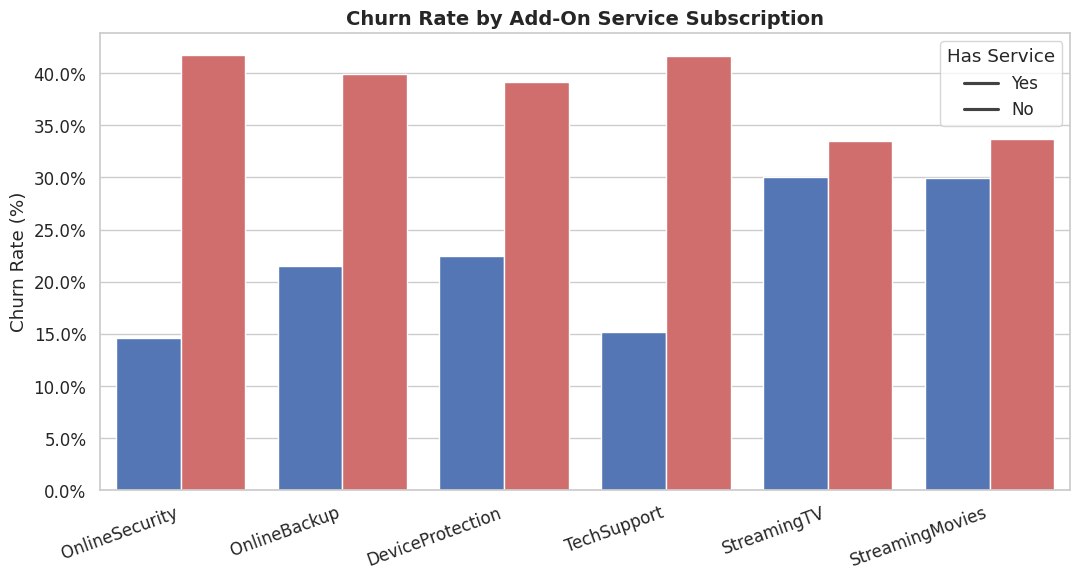

In [113]:

# Stacked Bar — Services vs Churn
services = ["OnlineSecurity", "OnlineBackup", "DeviceProtection",
            "TechSupport", "StreamingTV", "StreamingMovies"]

service_churn_data = []
for svc in services:
    for val in ["Yes", "No"]:
        subset = dp[dp[svc] == val]
        rate = subset["ChurnFlag"].mean() * 100
        service_churn_data.append({"Service": svc, "HasService": val, "ChurnRate": rate})

svc_df = pd.DataFrame(service_churn_data)

fig, ax = plt.subplots(figsize=(11, 6))
sns.barplot(data=svc_df, x="Service", y="ChurnRate", hue="HasService",
            palette={"Yes": "#4472C4", "No": "#E05C5C"}, ax=ax)
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.set_title("Churn Rate by Add-On Service Subscription",
             fontsize=14, fontweight="bold")
ax.set_xlabel("")
ax.set_ylabel("Churn Rate (%)")
ax.set_xticklabels(ax.get_xticklabels(), rotation=20, ha="right")
ax.legend(title="Has Service", labels=["Yes", "No"])
plt.tight_layout()
plt.show()